# O6 — feedback-driven surrogate depth

A held-out 20D condition with 15 instances and 1,500 trials. The feedback policy starts at depth 9. From trial 200 onward, every 100 trials it trains candidate forests on the chronologically older 80% of the runhistory and measures rank correlation on the newest 20%. It considers depths 9, 15, 20, and 30, prefers the smallest near-best depth, and enforces a 200-trial dwell time.

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd()
if HERE.name != "08_next_experiment":
    HERE = Path("/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o6_multi_modal/depth_policies/08_next_experiment")
OUTPUT_DIRECTORY = HERE / "smac_output"
DIMENSION = 20
N_INSTANCES = 15
N_TRIALS = 1500
PROBLEM_SEED = 52
SEEDS = tuple(range(5))
DEPTHS = (9, 15, 20, 30)
FIXED = tuple(f"fixed_depth_{depth}" for depth in DEPTHS)
STAGED = "staged_depth_3_6_9_20"
FEEDBACK = "feedback_rank_depth_9_15_20_30"
POLICIES = FIXED + (STAGED, FEEDBACK)
CHECKPOINTS = tuple(range(100, N_TRIALS + 1, 100))
LABELS = {f"fixed_depth_{depth}": f"depth = {depth}" for depth in DEPTHS}
LABELS.update({STAGED: "staged 3 → 6 → 9 → 20", FEEDBACK: "feedback-selected depth"})
COLORS = dict(zip(POLICIES, ("C0", "C1", "C2", "C3", "black", "C6")))

In [2]:
def load(policy):
    runs = {}
    for path in (OUTPUT_DIRECTORY / policy).rglob("trajectory.json"):
        result = json.loads(path.read_text())
        if result["smac_seed"] in SEEDS and result["n_trials"] == N_TRIALS and result["problem_seed"] == PROBLEM_SEED:
            runs[result["smac_seed"]] = result
    missing = sorted(set(SEEDS) - set(runs))
    if missing:
        raise FileNotFoundError(f"Missing {policy}: seeds={missing}")
    return runs

results = {policy: load(policy) for policy in POLICIES}
for policy, runs in results.items():
    for result in runs.values():
        assert result["problem"] == "O6-Multimodal"
        assert result["dimension"] == DIMENSION
        assert result["n_instances"] == N_INSTANCES
        assert len(result["instance_map"]) == N_INSTANCES
        assert result["problem_seed"] == PROBLEM_SEED
        assert result["pythonhashseed"] == "12345"
        assert result["initial_design"] == "random"
        assert result["n_initial_configs"] == 10
        assert result["initial_design_seed"] == result["smac_seed"]
        assert result["min_samples_leaf"] == 3
        assert result["min_samples_split"] == 3
        assert len(result["iteration"]) == N_TRIALS
        assert len(result["best_regret"]) == N_TRIALS
        if policy in FIXED:
            assert result["max_depth"] == int(policy.rsplit("_", 1)[1])
        elif policy == STAGED:
            assert result["stage_boundaries"] == [100, 200, 500]
            assert result["depth_schedule"] == [3, 6, 9, 20]
        else:
            assert result["candidate_depths"] == list(DEPTHS)
            assert result["feedback_start"] == 200
            assert result["feedback_interval"] == 100
            assert result["validation_fraction"] == 0.2
            assert result["min_dwell"] == 200
            assert [decision["scheduled_trial"] for decision in result["decisions"]] == list(range(200, N_TRIALS, 100))
            assert all(decision["scheduled_trial"] <= decision["completed_trials"] < decision["scheduled_trial"] + 100 for decision in result["decisions"])
            assert all(set(decision["scores"]) == {str(depth) for depth in DEPTHS} for decision in result["decisions"])
            switch_trials = [trial for trial, depth in result["transitions"]]
            assert all(right - left >= 200 for left, right in zip(switch_trials, switch_trials[1:]))
print(f"Loaded {sum(map(len, results.values()))}/30 validated trajectories.")

Loaded 30/30 validated trajectories.


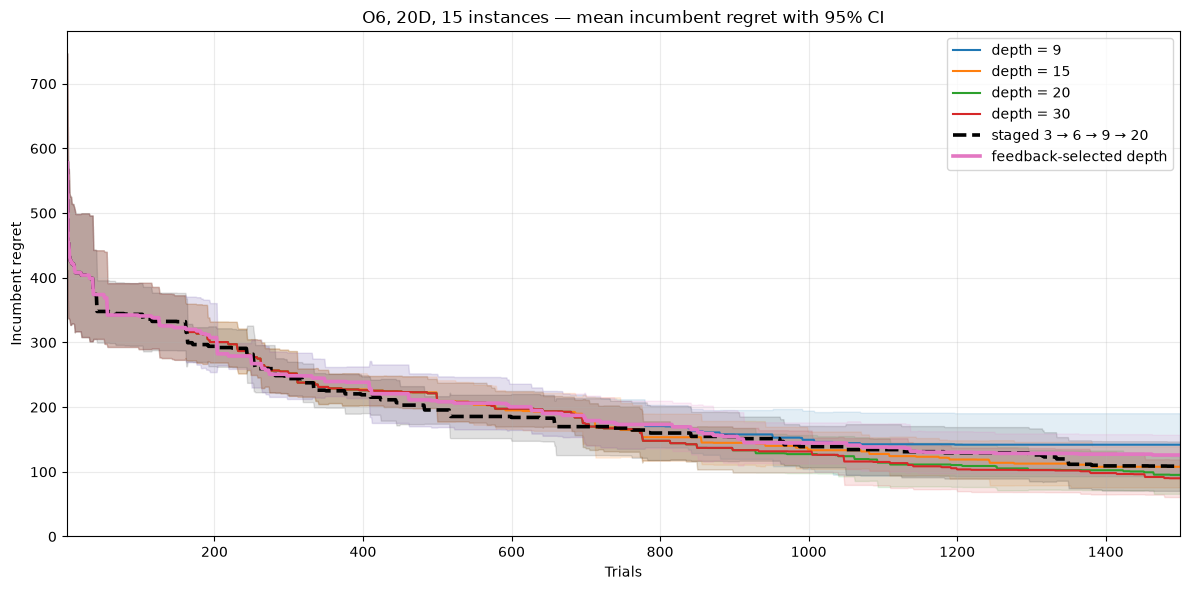

In [3]:
rows = [
    {"policy": policy, "seed": seed, "iteration": iteration, "best_regret": regret}
    for policy, runs in results.items()
    for seed, result in runs.items()
    for iteration, regret in zip(result["iteration"], result["best_regret"])
]
trajectories = pd.DataFrame(rows)
summary = trajectories.groupby(["policy", "iteration"])["best_regret"].agg(["mean", "std", "count"]).reset_index()
summary["ci95"] = 1.96 * summary["std"] / np.sqrt(summary["count"])

fig, ax = plt.subplots(figsize=(12, 6))
for policy in POLICIES:
    data = summary[summary.policy == policy]
    width = 2.6 if policy in (STAGED, FEEDBACK) else 1.5
    style = "--" if policy == STAGED else "-"
    ax.plot(data.iteration, data["mean"], label=LABELS[policy], color=COLORS[policy], linewidth=width, linestyle=style)
    ax.fill_between(data.iteration, np.maximum(0, data["mean"] - data.ci95), data["mean"] + data.ci95, color=COLORS[policy], alpha=.12)
ax.set(title="O6, 20D, 15 instances — mean incumbent regret with 95% CI", xlabel="Trials", ylabel="Incumbent regret", xlim=(1, N_TRIALS), ylim=(0, None))
ax.grid(alpha=.25)
ax.legend()
plt.tight_layout()
plt.show()

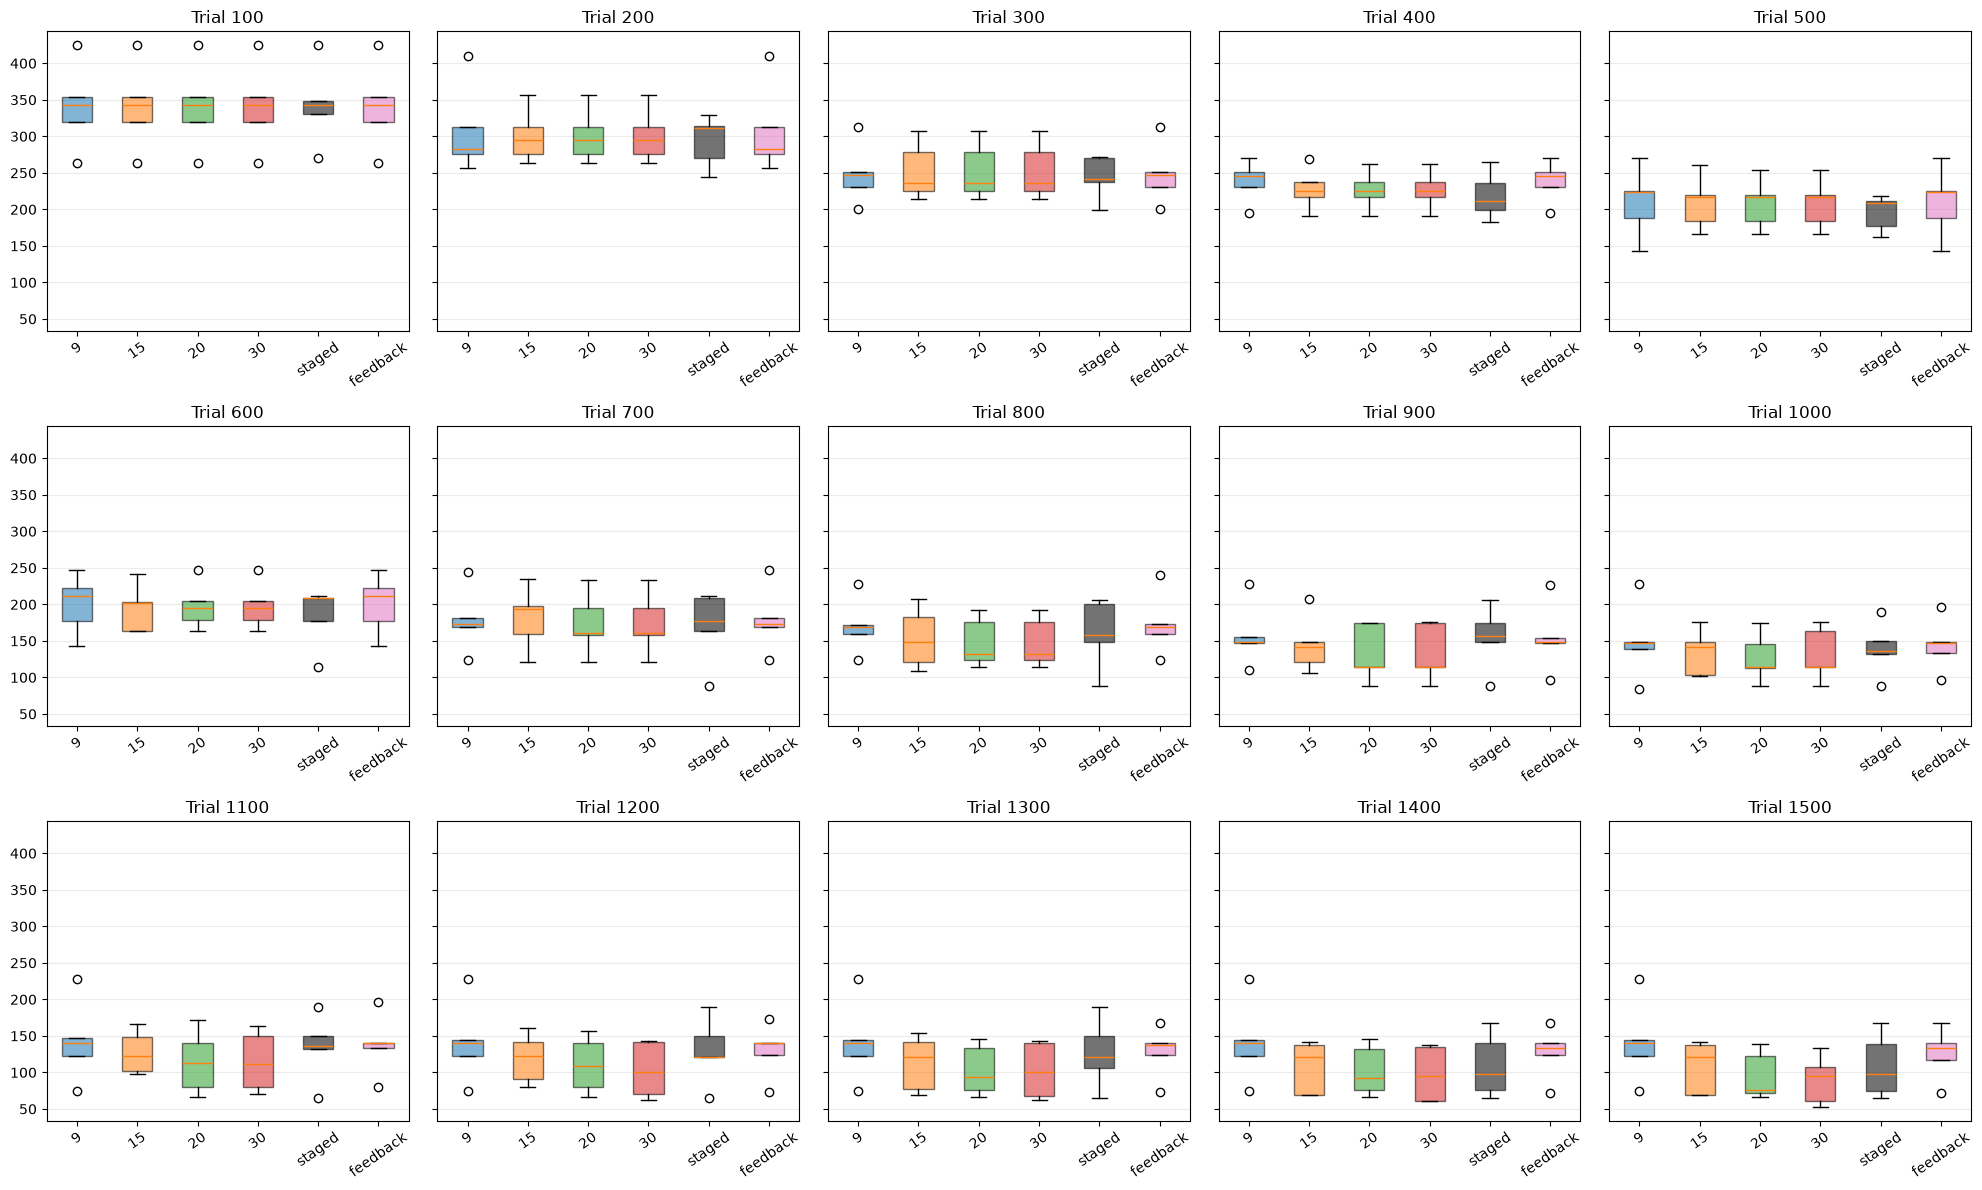

In [4]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12), sharey=True)
for ax, checkpoint in zip(axes.flat, CHECKPOINTS):
    values = [[results[policy][seed]["best_regret"][checkpoint - 1] for seed in SEEDS] for policy in POLICIES]
    boxes = ax.boxplot(values, patch_artist=True, tick_labels=[str(depth) for depth in DEPTHS] + ["staged", "feedback"])
    for box, policy in zip(boxes["boxes"], POLICIES):
        box.set(facecolor=COLORS[policy], alpha=.55)
    ax.set_title(f"Trial {checkpoint}")
    ax.tick_params(axis="x", rotation=35)
    ax.grid(axis="y", alpha=.25)
plt.tight_layout()
plt.show()

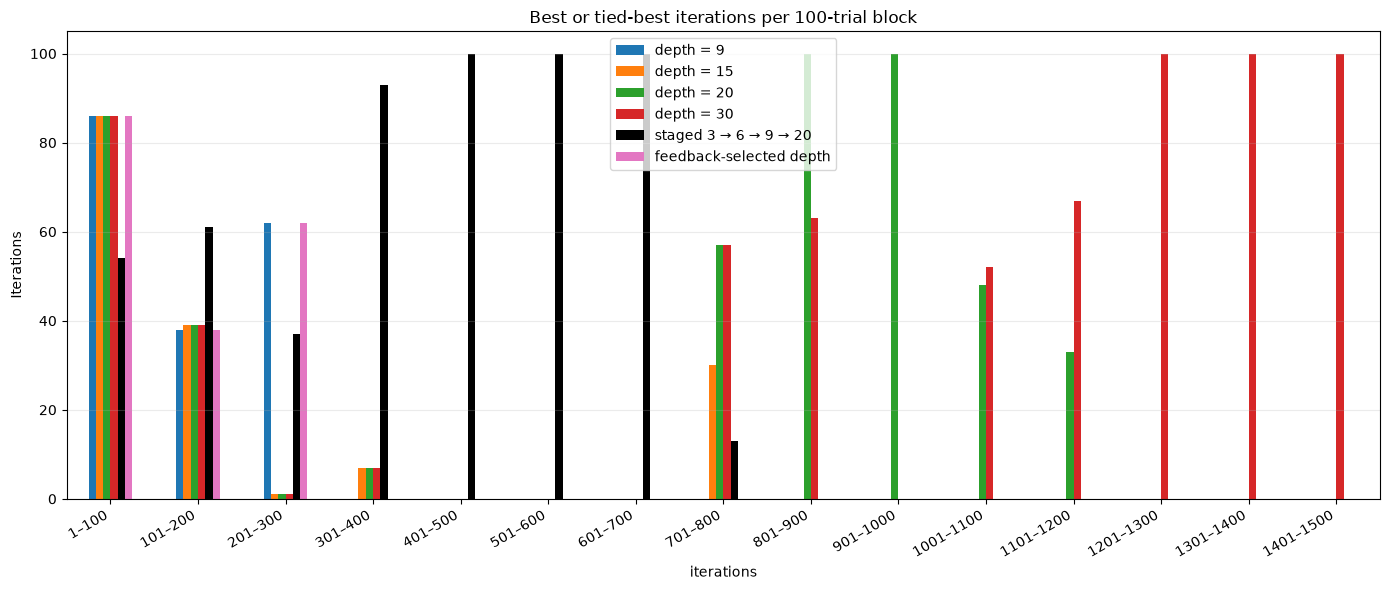

,iterations,superior policy,depth = 9,depth = 15,depth = 20,depth = 30,staged 3 → 6 → 9 → 20,feedback-selected depth
0,1–100,"depth = 9, depth = 15, depth = 20, depth = 30,...",86,86,86,86,54,86
1,101–200,staged 3 → 6 → 9 → 20,38,39,39,39,61,38
2,201–300,"depth = 9, feedback-selected depth",62,1,1,1,37,62
3,301–400,staged 3 → 6 → 9 → 20,0,7,7,7,93,0
4,401–500,staged 3 → 6 → 9 → 20,0,0,0,0,100,0
5,501–600,staged 3 → 6 → 9 → 20,0,0,0,0,100,0
6,601–700,staged 3 → 6 → 9 → 20,0,0,0,0,100,0
7,701–800,"depth = 20, depth = 30",0,30,57,57,13,0
8,801–900,depth = 20,0,0,100,63,0,0
9,901–1000,depth = 20,0,0,100,0,0,0


In [5]:
mean_regret = trajectories.pivot_table(index="iteration", columns="policy", values="best_regret", aggfunc="mean").reindex(columns=POLICIES)
best = mean_regret.min(axis=1)
wins = pd.DataFrame({policy: np.isclose(mean_regret[policy], best, rtol=1e-12, atol=1e-9) for policy in POLICIES}, index=mean_regret.index)
block_rows = []
for end in CHECKPOINTS:
    counts = wins.loc[end - 99:end].sum()
    maximum = int(counts.max())
    row = {"iterations": f"{end - 99}–{end}", "superior policy": ", ".join(LABELS[policy] for policy in POLICIES if counts[policy] == maximum)}
    row.update({LABELS[policy]: int(counts[policy]) for policy in POLICIES})
    block_rows.append(row)
block_superiority = pd.DataFrame(block_rows)
ax = block_superiority.set_index("iterations")[[LABELS[policy] for policy in POLICIES]].plot(kind="bar", figsize=(14, 6), color=[COLORS[policy] for policy in POLICIES])
ax.set(title="Best or tied-best iterations per 100-trial block", ylabel="Iterations", ylim=(0, 105))
ax.grid(axis="y", alpha=.25)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", None):
    display(block_superiority)

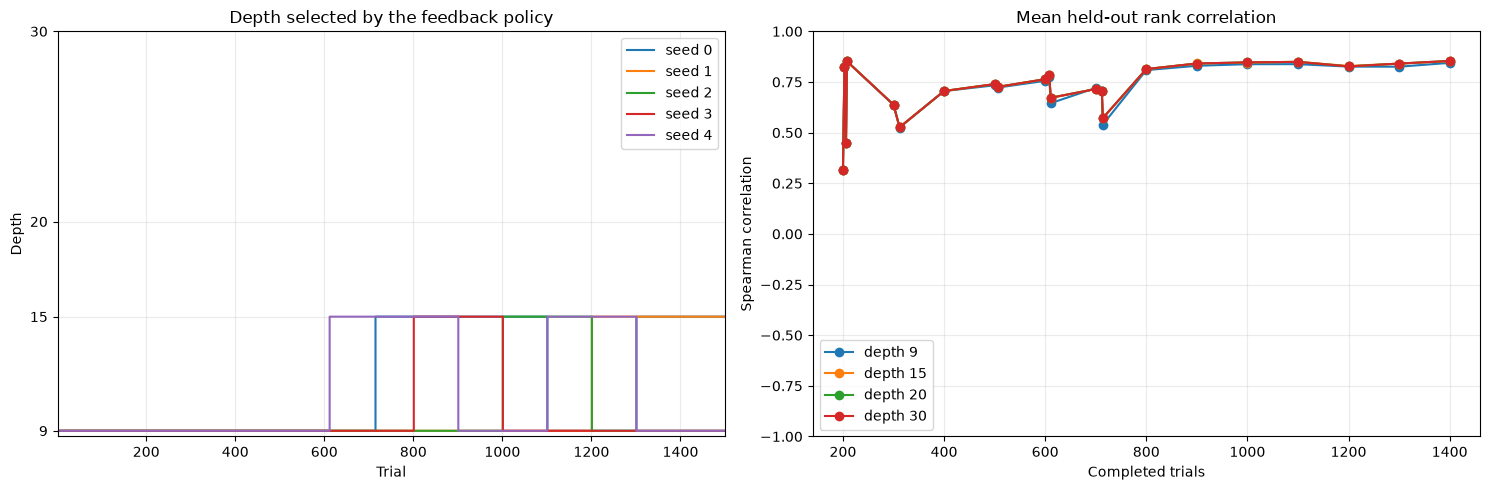

In [6]:
depth_rows = []
score_rows = []
for seed, result in results[FEEDBACK].items():
    transitions = result["transitions"]
    transition_index = 0
    current_depth = transitions[0][1]
    for iteration in range(1, N_TRIALS + 1):
        completed = iteration - 1
        while transition_index + 1 < len(transitions) and transitions[transition_index + 1][0] <= completed:
            transition_index += 1
            current_depth = transitions[transition_index][1]
        depth_rows.append({"seed": seed, "iteration": iteration, "depth": current_depth})
    for decision in result["decisions"]:
        for depth, score in decision["scores"].items():
            score_rows.append({"seed": seed, "completed_trials": decision["completed_trials"], "depth": int(depth), "rank_correlation": score})

depth_history = pd.DataFrame(depth_rows)
score_history = pd.DataFrame(score_rows)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for seed in SEEDS:
    data = depth_history[depth_history.seed == seed]
    axes[0].step(data.iteration, data.depth, where="post", label=f"seed {seed}")
for depth in DEPTHS:
    data = score_history[score_history.depth == depth].groupby("completed_trials")["rank_correlation"].mean()
    axes[1].plot(data.index, data.values, marker="o", label=f"depth {depth}")
axes[0].set(title="Depth selected by the feedback policy", xlabel="Trial", ylabel="Depth", yticks=DEPTHS, xlim=(1, N_TRIALS))
axes[1].set(title="Mean held-out rank correlation", xlabel="Completed trials", ylabel="Spearman correlation", ylim=(-1, 1))
for ax in axes:
    ax.grid(alpha=.25)
    ax.legend()
plt.tight_layout()
plt.show()

In [7]:
run_rows = []
for policy, runs in results.items():
    for seed, result in runs.items():
        regret = np.asarray(result["best_regret"], dtype=float)
        run_rows.append({"policy": LABELS[policy], "seed": seed, "final_regret": regret[-1], "mean_incumbent_regret": regret.mean()})
run_metrics = pd.DataFrame(run_rows)
metric_summary = run_metrics.groupby("policy")[["final_regret", "mean_incumbent_regret"]].agg(["mean", "std", "median", "min", "max"]).sort_values(("final_regret", "mean"))
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", None):
    display(metric_summary)
    display(run_metrics.sort_values(["seed", "final_regret"]))

final_regret                                    \
                                mean        std      median        min   
policy                                                                   
depth = 30                 90.006300  33.208672   95.660435  52.566515   
depth = 20                 95.248759  33.389341   76.330904  66.078762   
depth = 15                107.769018  36.236950  121.608534  68.830136   
staged 3 → 6 → 9 → 20     108.752810  43.629345   97.939624  64.914148   
feedback-selected depth   125.974343  35.637136  132.938735  71.354413   
depth = 9                 141.908238  55.544062  140.269965  74.537729   

                                    mean_incumbent_regret             \
                                max                  mean        std   
policy                                                                 
depth = 30               132.816990            186.473883  24.290136   
depth = 20               139.181485            187.226004  22.355447   
depth = 15               141.379858            191.847120  26.534244   
staged 3 → 6 → 9 → 20    167.811064            190.832772  25.550850   
feedback-selected depth  167.746367            198.254006  35.904262   
depth = 9                228.031360            202.470175  42.129855   

                                                             
                             median         min         max  
policy                                                       
depth = 30               179.891800  157.365279  223.589369  
depth = 20               181.957959  159.790405  219.734042  
depth = 15               190.135936  158.166230  232.431107  
staged 3 → 6 → 9 → 20    187.490778  158.293918  228.480766  
feedback-selected depth  196.148776  150.070545  246.535303  
depth = 9                196.501532  150.503711  264.656845

,policy,seed,final_regret,mean_incumbent_regret
14,depth = 20,0,71.714788,178.329146
24,staged 3 → 6 → 9 → 20,0,74.318098,187.490778
19,depth = 30,0,95.660435,179.022279
29,feedback-selected depth,0,116.958411,196.148776
9,depth = 15,0,121.608534,192.283980
4,depth = 9,0,122.500733,196.501532
18,depth = 30,1,52.566515,179.891800
23,staged 3 → 6 → 9 → 20,1,64.914148,158.293918
13,depth = 20,1,66.078762,181.957959
8,depth = 15,1,69.025701,186.218348


In [8]:
checkpoint_table = trajectories[trajectories.iteration.isin(CHECKPOINTS)].groupby(["iteration", "policy"])["best_regret"].agg(["mean", "std", "min", "median", "max"])
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", None):
    display(checkpoint_table)

mean        std         min  \
iteration policy                                                              
100       feedback_rank_depth_9_15_20_30  340.961402  58.494489  263.472800   
          fixed_depth_15                  340.961402  58.494489  263.472800   
          fixed_depth_20                  340.961402  58.494489  263.472800   
          fixed_depth_30                  340.961402  58.494489  263.472800   
          fixed_depth_9                   340.961402  58.494489  263.472800   
          staged_depth_3_6_9_20           343.486422  55.211317  270.382112   
200       feedback_rank_depth_9_15_20_30  307.547296  60.815940  256.281598   
          fixed_depth_15                  300.629829  36.115159  263.472800   
          fixed_depth_20                  300.629829  36.115159  263.472800   
          fixed_depth_30                  300.629829  36.115159  263.472800   
          fixed_depth_9                   307.547296  60.815940  256.281598   
          staged_depth_3_6_9_20           294.065158  35.152142  244.927450   
300       feedback_rank_depth_9_15_20_30  248.465609  40.911838  200.837718   
          fixed_depth_15                  251.966203  39.596722  213.642947   
          fixed_depth_20                  251.966203  39.596722  213.642947   
          fixed_depth_30                  251.966203  39.596722  213.642947   
          fixed_depth_9                   248.465609  40.911838  200.837718   
          staged_depth_3_6_9_20           244.162376  29.694435  199.408147   
400       feedback_rank_depth_9_15_20_30  238.461212  27.804083  195.318662   
          fixed_depth_15                  227.360713  28.577560  190.457159   
          fixed_depth_20                  226.098044  26.362971  190.457159   
          fixed_depth_30                  226.098044  26.362971  190.457159   
          fixed_depth_9                   238.461212  27.804083  195.318662   
          staged_depth_3_6_9_20           219.108933  32.352097  182.717374   
500       feedback_rank_depth_9_15_20_30  209.961818  47.234120  143.199184   
          fixed_depth_15                  209.473069  36.601595  166.047573   
          fixed_depth_20                  207.980579  34.038316  166.047573   
          fixed_depth_30                  207.980579  34.038316  166.047573   
          fixed_depth_9                   209.961818  47.234120  143.199184   
          staged_depth_3_6_9_20           195.624328  24.332673  162.807518   
600       feedback_rank_depth_9_15_20_30  200.447118  40.653363  143.199184   
          fixed_depth_15                  195.030871  32.415058  164.107152   
          fixed_depth_20                  197.508751  31.324377  164.107152   
          fixed_depth_30                  197.508751  31.324377  164.107152   
          fixed_depth_9                   200.447118  40.653363  143.199184   
          staged_depth_3_6_9_20           184.109532  41.294325  114.840825   
700       feedback_rank_depth_9_15_20_30  179.181023  44.093192  124.166832   
          fixed_depth_15                  181.044712  43.157171  120.512421   
          fixed_depth_20                  173.706816  42.667643  120.512421   
          fixed_depth_30                  173.706816  42.667643  120.512421   
          fixed_depth_9                   178.567185  42.916973  124.166832   
          staged_depth_3_6_9_20           169.846065  50.229906   87.918079   
800       feedback_rank_depth_9_15_20_30  173.225114  41.893175  124.166832   
          fixed_depth_15                  153.416151  41.410348  108.253998   
          fixed_depth_20                  147.957803  34.331901  114.125845   
          fixed_depth_30                  147.957803  34.331901  114.125845   
          fixed_depth_9                   170.704268  37.344439  124.166832   
          staged_depth_3_6_9_20           159.958993  47.598990   87.918079   
900       feedback_rank_depth_9_15_20_30  154.661135  46.359666   96.361249   
          fixed_dep